In [27]:
# ============================================
# IMPORT LIBRARIES
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# ============================================
# DATA ACQUISITION & CLEANING
# ============================================
# Load the dataset
df = pd.read_csv('heart.csv')

In [29]:
# Display first 5 rows to verify loading
print("First 5 rows:")
print(df.head())

First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [30]:
# Check dataset info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [31]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [32]:
# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
df = df.drop_duplicates()


Duplicate rows: 0


In [33]:
# Check data types
print("\nData Types:")
print(df.dtypes)

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())


Data Types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Basic Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          O

In [34]:
# Clean column names (make lowercase)
df.columns = df.columns.str.lower()

In [35]:
# ============================================
# QUESTION 1: Statistical Analysis
# ============================================
print("\n" + "="*50)
print("QUESTION 1: Statistical Analysis")
print("="*50)

# Mean values for patients with and without heart disease
stats = df.groupby('heartdisease')[['age', 'maxhr', 'cholesterol']].mean()
print("Average Age, MaxHR, and Cholesterol by Heart Disease Status:")
print(stats)

print("\nInterpretation: Patients with heart disease tend to be older, have lower maximum heart rate, and have higher cholesterol levels on average.")


QUESTION 1: Statistical Analysis
Average Age, MaxHR, and Cholesterol by Heart Disease Status:
                    age       maxhr  cholesterol
heartdisease                                    
0             50.551220  148.151220   227.121951
1             55.899606  127.655512   175.940945

Interpretation: Patients with heart disease tend to be older, have lower maximum heart rate, and have higher cholesterol levels on average.


In [36]:
# ============================================
# QUESTION 2: Conditional Filtering (Multiple Conditions)
# ============================================
print("\n" + "="*50)
print("QUESTION 2: Male Patients Over 50 with Heart Disease")
print("="*50)

male_over50_with_hd = df[(df['sex'] == 'M') &
                          (df['age'] > 50) &
                          (df['heartdisease'] == 1)]

print(f"Number of male patients over 50 with heart disease: {len(male_over50_with_hd)}")
print(f"Percentage: {(len(male_over50_with_hd) / len(df[df['heartdisease'] == 1]) * 100):.2f}% of all heart disease patients")



QUESTION 2: Male Patients Over 50 with Heart Disease
Number of male patients over 50 with heart disease: 344
Percentage: 67.72% of all heart disease patients


In [37]:
# ============================================
# QUESTION 3: Conditional Filtering
# ============================================
print("\n" + "="*50)
print("QUESTION 3: Average Cholesterol for ASY + ExerciseAngina Patients")
print("="*50)

high_risk_patients = df[(df['chestpaintype'] == 'ASY') & (df['exerciseangina'] == 'Y')]
avg_cholesterol = high_risk_patients['cholesterol'].mean()

print(f"Number of patients with ASY chest pain and exercise angina: {len(high_risk_patients)}")
print(f"Average cholesterol among these patients: {avg_cholesterol:.2f} mm/dl")



QUESTION 3: Average Cholesterol for ASY + ExerciseAngina Patients
Number of patients with ASY chest pain and exercise angina: 297
Average cholesterol among these patients: 195.59 mm/dl


In [38]:
# ============================================
# QUESTION 4: Grouping
# ============================================
print("\n" + "="*50)
print("QUESTION 4: Heart Disease Cases by Chest Pain Type")
print("="*50)

chestpain_hd = df[df['heartdisease'] == 1].groupby('chestpaintype').size()
print("Heart disease cases by chest pain type:")
print(chestpain_hd)


QUESTION 4: Heart Disease Cases by Chest Pain Type
Heart disease cases by chest pain type:
chestpaintype
ASY    392
ATA     24
NAP     72
TA      20
dtype: int64


In [39]:
# ============================================
# QUESTION 5: Sorting
# ============================================
print("\n" + "="*50)
print("QUESTION 5: Top 10 Cholesterol Levels in Heart Disease Patients")
print("="*50)

top10_cholesterol = df[df['heartdisease'] == 1].sort_values('cholesterol', ascending=False)[['age', 'sex', 'cholesterol', 'chestpaintype']].head(10)
print("Top 10 heart disease patients by cholesterol:")
print(top10_cholesterol)



QUESTION 5: Top 10 Cholesterol Levels in Heart Disease Patients
Top 10 heart disease patients by cholesterol:
     age sex  cholesterol chestpaintype
149   54   M          603           ASY
76    32   M          529           ASY
30    53   M          518           NAP
250   44   M          491           ASY
103   40   M          466           ASY
796   56   F          409           ASY
624   63   F          407           ASY
182   52   M          404           ASY
123   58   F          393           ATA
102   40   F          392           ASY


In [40]:
# ============================================
# QUESTION 6: Combination (Grouping + Sorting)
# ============================================
print("\n" + "="*50)
print("QUESTION 6: Average Age by Chest Pain Type (Sorted)")
print("="*50)

avg_age_by_chestpain = df.groupby('chestpaintype')['age'].mean().sort_values(ascending=False)
print("Average age by chest pain type (oldest to youngest):")
print(avg_age_by_chestpain)


QUESTION 6: Average Age by Chest Pain Type (Sorted)
Average age by chest pain type (oldest to youngest):
chestpaintype
ASY    54.959677
TA     54.826087
NAP    53.310345
ATA    49.242775
Name: age, dtype: float64


In [41]:
# ============================================
# QUESTION 7: Combination (Filtering + Grouping)
# ============================================
print("\n" + "="*50)
print("QUESTION 7: Average RestingBP by Gender (Heart Disease Patients Only)")
print("="*50)

avg_bp_by_sex = df[df['heartdisease'] == 1].groupby('sex')['restingbp'].mean()
print("Average resting blood pressure by gender (heart disease patients):")
print(avg_bp_by_sex)


QUESTION 7: Average RestingBP by Gender (Heart Disease Patients Only)
Average resting blood pressure by gender (heart disease patients):
sex
F    142.000000
M    133.331878
Name: restingbp, dtype: float64



QUESTION 8: Age Distribution by Heart Disease Status


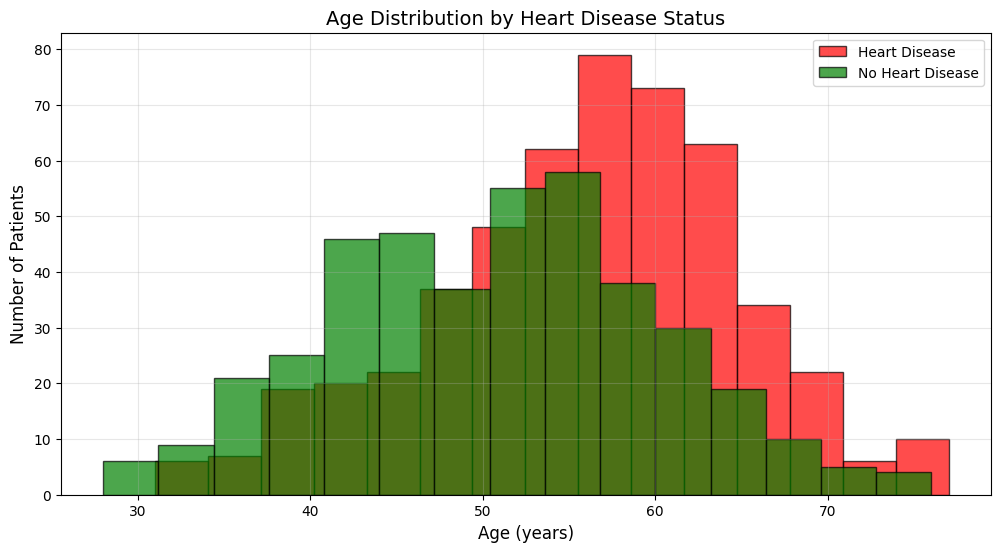

In [42]:
# ============================================
# QUESTION 8: Visualization - Histogram
# ============================================
print("\n" + "="*50)
print("QUESTION 8: Age Distribution by Heart Disease Status")
print("="*50)

plt.figure(figsize=(12, 6))
# Create histogram for patients with heart disease
plt.hist(df[df['heartdisease'] == 1]['age'], bins=15, alpha=0.7, label='Heart Disease', color='red', edgecolor='black')
# Create histogram for patients without heart disease
plt.hist(df[df['heartdisease'] == 0]['age'], bins=15, alpha=0.7, label='No Heart Disease', color='green', edgecolor='black')

plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



QUESTION 9: Heart Disease Cases by Sex


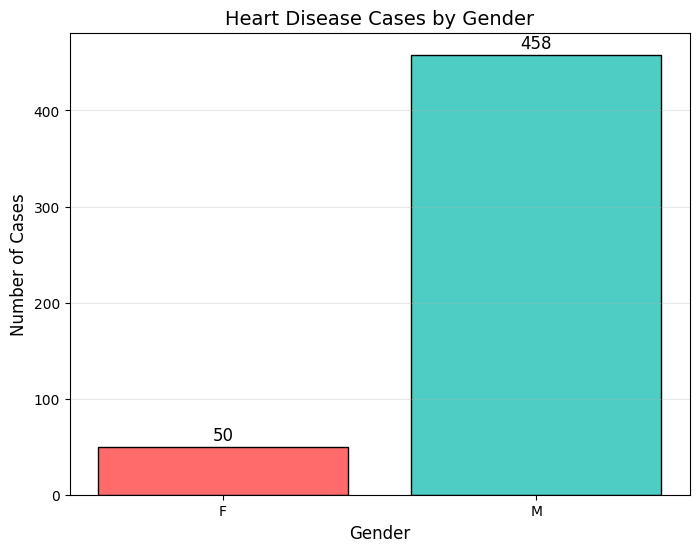

In [43]:
# ============================================
# QUESTION 9: Visualization - Bar Chart
# ============================================
print("\n" + "="*50)
print("QUESTION 9: Heart Disease Cases by Sex")
print("="*50)

# Count heart disease by sex
hd_by_sex = df[df['heartdisease'] == 1].groupby('sex').size()

plt.figure(figsize=(8, 6))
colors = ['#ff6b6b', '#4ecdc4']
bars = plt.bar(hd_by_sex.index, hd_by_sex.values, color=colors, edgecolor='black')

plt.title('Heart Disease Cases by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{int(height)}',
             ha='center', va='bottom', fontsize=12)

plt.grid(True, alpha=0.3, axis='y')
plt.show()


QUESTION 10: Chest Pain Type Distribution (Heart Disease Patients)


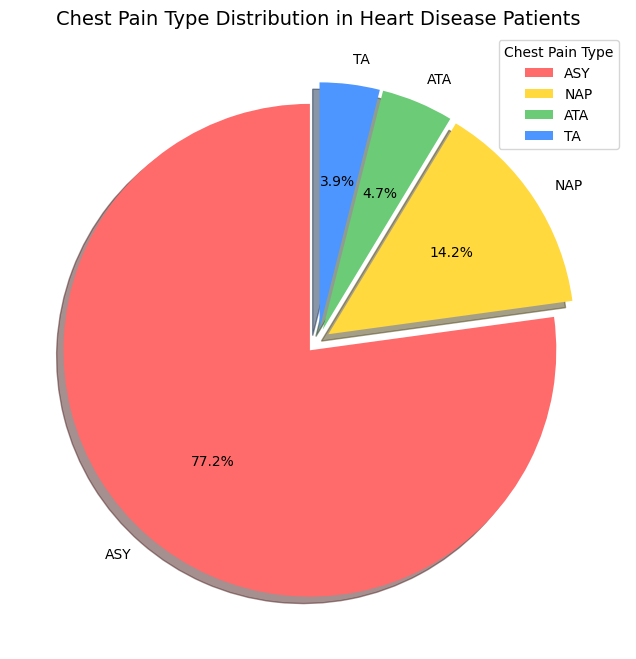


INTERPRETATION SUMMARY

Key Findings:
1. Heart disease patients tend to be older with lower maximum heart rates.
2. Asymptomatic (ASY) chest pain is the most common type among heart disease patients.
3. Male patients over 50 represent a significant portion of heart disease cases.
4. Patients with ASY chest pain AND exercise angina have higher cholesterol levels.
5. Males with heart disease have higher average resting blood pressure than females.
6. The majority of heart disease cases are in males.

Recommendations:
1. Healthcare providers should pay special attention to patients over 50 with asymptomatic chest pain.
2. Regular cholesterol screening should be prioritized for patients with exercise-induced angina.
3. Lifestyle interventions for cholesterol management should target patients with ASY chest pain.



In [44]:
# ============================================
# QUESTION 10: Visualization - Pie Chart
# ============================================
print("\n" + "="*50)
print("QUESTION 10: Chest Pain Type Distribution (Heart Disease Patients)")
print("="*50)

chestpain_hd_counts = df[df['heartdisease'] == 1]['chestpaintype'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff']
plt.pie(chestpain_hd_counts.values,
        labels=chestpain_hd_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=[0.05, 0.05, 0.05, 0.05],
        shadow=True)

plt.title('Chest Pain Type Distribution in Heart Disease Patients', fontsize=14)
plt.legend(chestpain_hd_counts.index, title='Chest Pain Type', loc='upper right')
plt.show()

print("\n" + "="*50)
print("INTERPRETATION SUMMARY")
print("="*50)
print("""
Key Findings:
1. Heart disease patients tend to be older with lower maximum heart rates.
2. Asymptomatic (ASY) chest pain is the most common type among heart disease patients.
3. Male patients over 50 represent a significant portion of heart disease cases.
4. Patients with ASY chest pain AND exercise angina have higher cholesterol levels.
5. Males with heart disease have higher average resting blood pressure than females.
6. The majority of heart disease cases are in males.

Recommendations:
1. Healthcare providers should pay special attention to patients over 50 with asymptomatic chest pain.
2. Regular cholesterol screening should be prioritized for patients with exercise-induced angina.
3. Lifestyle interventions for cholesterol management should target patients with ASY chest pain.
""")